,dataset,total_attributes,discovered_fd_count,reference_fd_count,exact_fd_matches,discovered_all_attr_count,reference_all_attr_count,all_overlap_count,all_discovered_only_count,all_reference_only_count,discovered_rhs_count,reference_rhs_count,rhs_overlap_count,rhs_discovered_only_count,rhs_reference_only_count
0,Allergen,22,163,21,21,22,22,22,0,0,21,21,21,0,0
1,Beers,10,25,3,3,10,4,4,6,0,10,3,3,7,0
2,Eudract,11,36,11,8,11,9,9,2,0,10,8,8,2,0
3,Flights,6,11,4,4,5,5,5,0,0,5,4,4,1,0
4,Hospital,19,124,6,5,19,4,4,15,0,17,4,4,13,0
5,Rayyan,11,34,3,0,11,3,2,9,1,11,2,2,9,0
6,Tax,15,18,4,4,15,6,6,9,0,14,3,3,11,0



Allergen
Exact matches (21):
  code -> almondnuts
  code -> brazil nuts
  code -> cashew
  code -> celery
  code -> crustaceans
  code -> eggs
  code -> fish
  code -> gluten
  code -> hazelnut
  code -> lupin
  code -> macadamia nuts
  code -> milk
  code -> molluscs
  code -> mustard
  code -> nuts
  code -> peanut
  code -> pistachio
  code -> sesame
  code -> soy
  code -> sulfite
  code -> walnut

Only in reference (0):

Only in discovered (142):
  almondnuts -> brazil nuts
  almondnuts -> crustaceans
  almondnuts -> fish
  almondnuts -> macadamia nuts
  almondnuts -> molluscs
  almondnuts -> pistachio
  almondnuts -> sulfite
  brazil nuts -> crustaceans
  brazil nuts -> fish
  brazil nuts -> macadamia nuts
  brazil nuts -> molluscs
  brazil nuts -> pistachio
  brazil nuts -> sulfite
  cashew -> brazil nuts
  cashew -> crustaceans
  cashew -> fish
  cashew -> macadamia nuts
  cashew -> molluscs
  cashew -> pistachio
  cashew -> sulfite
  cashew -> walnut
  celery -> brazil nuts
 

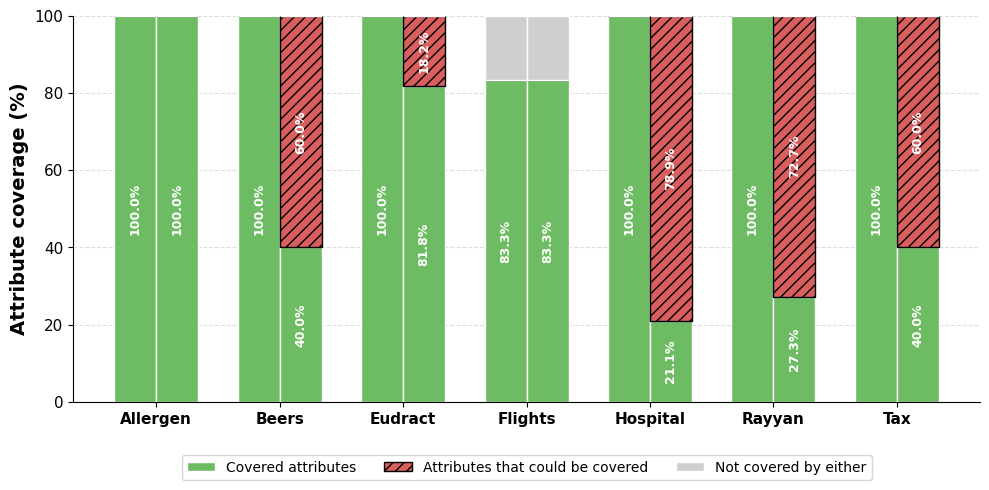

In [50]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("../data")

REFERENCE_TEXT = r"""
Hospital: city -> zipcode; city -> countyname; zipcode -> city; zipcode -> state; zipcode -> countyname; countyname -> state
Flights: flight -> act dep time; flight -> act arr time; flight -> sched dep time; flight -> sched arr time
Address: address -> state; address -> zip; zip -> state
Beers: id -> brewery-name; id -> city; id -> state
Rayyan: journal abbreviation -> journal title; journal abbreviation -> journal issn; journal issn -> journal title
IT: -
Tax: zip -> city; zip -> state; f name -> gender; area code -> state
Allergen: code -> nuts; code -> almondnuts; code -> brazil_nuts; code -> macadamia_nuts; code -> hazelnut; code -> pistachio; code -> walnut; code -> cashew; code -> celery; code -> crustaceans; code -> eggs; code -> fish; code -> gluten; code -> lupin; code -> milk; code -> molluscs; code -> mustard; code -> peanut; code -> sesame; code -> soy; code -> sulfite
Eudract: eudract_number -> open; eudract_number -> single_blind; eudract_number -> double_blind; eudract_number -> controlled; eudract_number -> randomised; eudract_number -> crossover; eudract_number -> parallel_group; eudract_number -> arms; single_blind,open -> double_blind; double_blind,open -> single_blind; single_blind,double_blind -> open
"""

DATASET_ATTR_COUNTS = {
    "Hospital": 19,
    "Flights": 6,
    "Beers": 10,
    "Rayyan": 11,
    "Tax": 15,
    "Allergen": 22,
    "Eudract": 11,
}

# ============================================================
# HELPERS
# ============================================================
def capitalize_first(value: str) -> str:
    return value[:1].upper() + value[1:]
    
def normalize_name(s: str) -> str:
    s = s.strip().lower()
    s = s.replace(r"$\rightarrow$", "->")
    s = s.replace("→", "->")
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s)
    return s

def parse_fd_line(line: str):
    """
    Parse one FD line like:
      code -> almondnuts [measure=1.0, gpdep=...]
      single_blind,open -> double_blind
    Returns: (lhs_tuple, rhs) or None
    """
    line = line.strip()
    if not line or line.startswith("--"):
        return None

    # remove trailing metrics
    line = re.sub(r"\s*\[.*\]\s*$", "", line)

    m = re.match(r"^(.*?)\s*->\s*(.*?)$", line)
    if not m:
        return None

    lhs_raw, rhs_raw = m.groups()
    lhs = tuple(sorted(
        normalize_name(x) for x in lhs_raw.split(",") if x.strip()
    ))
    rhs = normalize_name(rhs_raw)

    if not lhs or not rhs:
        return None
    return (lhs, rhs)

def parse_discovered_fd_file(path: Path):
    """
    Ignore the first line, parse all remaining FD lines.
    """
    fds = set()
    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines[1:]:  # ignore first line
        fd = parse_fd_line(line)
        if fd is not None:
            fds.add(fd)
    return fds

def infer_dataset_from_filename(path: Path):
    stem = normalize_name(path.stem).replace(" ", "")
    for dataset in DATASET_ATTR_COUNTS:
        ds = normalize_name(dataset).replace(" ", "")
        if ds in stem or stem in ds:
            return dataset
    return None

def parse_reference_fds(raw_text: str):
    """
    Parse human-readable reference FDs like:

    Hospital: city -> zip; city -> county
    IT: -
    Eudract: a -> b; x,y -> z
    """
    ref = {}

    for raw_line in raw_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue

        if ":" not in line:
            continue

        dataset, rhs_text = line.split(":", 1)
        dataset = dataset.strip().title()   # allergen -> Allergen
        rhs_text = rhs_text.strip()

        ref.setdefault(dataset, set())

        if rhs_text == "-":
            continue

        for part in rhs_text.split(";"):
            fd = parse_fd_line(part)
            if fd is not None:
                ref[dataset].add(fd)

    return ref

def remove_fds_with_excluded_attrs(fds, banned_attrs):
    """
    Remove every FD where any banned attribute appears
    either in the LHS or as the RHS.
    """
    banned_attrs = {normalize_name(a) for a in banned_attrs}
    filtered = set()

    for lhs, rhs in fds:
        attrs_in_fd = set(lhs) | {rhs}
        if attrs_in_fd.isdisjoint(banned_attrs):
            filtered.add((lhs, rhs))

    return filtered
# ============================================================
# LOAD DISCOVERED FDs
# ============================================================
EXCLUDED_DISCOVERY_ATTRS = {
    "Beers": {"index"},
    "Flights": {"tuple id"},
    "Hospital": {"index"},
}

discovered_fds = {k: set() for k in DATASET_ATTR_COUNTS}

for path in DATA_ROOT.glob("*/clean/*.txt"):
    folder_name = path.parent.parent.name
    dataset = capitalize_first(folder_name)

    parsed_fds = parse_discovered_fd_file(path)

    # remove polluted FDs for specific datasets
    if dataset in EXCLUDED_DISCOVERY_ATTRS:
        parsed_fds = remove_fds_with_excluded_attrs(
            parsed_fds,
            EXCLUDED_DISCOVERY_ATTRS[dataset]
        )

    discovered_fds[dataset] |= parsed_fds

reference_fds = parse_reference_fds(REFERENCE_TEXT)

# ============================================================
# COMPUTE METRICS
# ============================================================
rows = []

for dataset, total_attrs in DATASET_ATTR_COUNTS.items():
    disc = discovered_fds.get(dataset, set())
    ref = reference_fds.get(dataset, set())

    # exact FD matches are optional, keep only if you still want them
    exact_matches = disc & ref

    # --- ALL attributes appearing anywhere in the FDs ---
    disc_all_attrs = set()
    for lhs, rhs in disc:
        disc_all_attrs.update(lhs)
        disc_all_attrs.add(rhs)

    ref_all_attrs = set()
    for lhs, rhs in ref:
        ref_all_attrs.update(lhs)
        ref_all_attrs.add(rhs)

    # overlap between discovered and reference attribute coverage
    all_both = disc_all_attrs & ref_all_attrs
    all_disc_only = disc_all_attrs - ref_all_attrs
    all_ref_only = ref_all_attrs - disc_all_attrs

    # keep RHS too, since you said that part is correct
    disc_rhs = {rhs for _, rhs in disc}
    ref_rhs = {rhs for _, rhs in ref}
    rhs_both = disc_rhs & ref_rhs
    rhs_disc_only = disc_rhs - ref_rhs
    rhs_ref_only = ref_rhs - disc_rhs

    rows.append({
        "dataset": dataset,
        "total_attributes": total_attrs,

        "discovered_fd_count": len(disc),
        "reference_fd_count": len(ref),
        "exact_fd_matches": len(exact_matches),

        # ALL-ATTRIBUTE coverage
        "discovered_all_attr_count": len(disc_all_attrs),
        "reference_all_attr_count": len(ref_all_attrs),
        "all_overlap_count": len(all_both),
        "all_discovered_only_count": len(all_disc_only),
        "all_reference_only_count": len(all_ref_only),

        # RHS-only coverage
        "discovered_rhs_count": len(disc_rhs),
        "reference_rhs_count": len(ref_rhs),
        "rhs_overlap_count": len(rhs_both),
        "rhs_discovered_only_count": len(rhs_disc_only),
        "rhs_reference_only_count": len(rhs_ref_only),
    })

df = pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)
display(df)

# ============================================================
for dataset in df["dataset"]:
    disc = discovered_fds.get(dataset, set())
    ref = reference_fds.get(dataset, set())

    print(f"\n{'='*70}")
    print(dataset)
    print(f"{'='*70}")
    print(f"Exact matches ({len(disc & ref)}):")
    for lhs, rhs in sorted(disc & ref):
        print(f"  {', '.join(lhs)} -> {rhs}")

    print(f"\nOnly in reference ({len(ref - disc)}):")
    for lhs, rhs in sorted(ref - disc):
        print(f"  {', '.join(lhs)} -> {rhs}")

    print(f"\nOnly in discovered ({len(disc - ref)}):")
    for lhs, rhs in sorted(disc - ref):
        print(f"  {', '.join(lhs)} -> {rhs}")

# ============================================================
# BUILD ARRAYS FOR THE PLOT
# ============================================================
# Left bar  = plain/reference FDs
# Right bar = discovered FDs

tables = df["dataset"].tolist()
total_attributes = df["total_attributes"].to_numpy()

# actual covered attributes
covered_bar1 = df["discovered_all_attr_count"].to_numpy()   # left
covered_bar2 = df["reference_all_attr_count"].to_numpy()    # right
#covered_bar1 = df["discovered_rhs_count"].to_numpy()   # left
#covered_bar2 = df["reference_rhs_count"].to_numpy()    # right

# max covered within each left/right pair
pair_max = np.maximum(covered_bar1, covered_bar2)

# red = gap up to pair max
missed_bar1 = pair_max - covered_bar1
missed_bar2 = pair_max - covered_bar2

# gray = everything above the pair max up to full relation size
rest_bar1 = total_attributes - pair_max
rest_bar2 = total_attributes - pair_max

def to_pct(x, totals):
    return x / totals * 100

covered_bar1_pct = to_pct(covered_bar1, total_attributes)
missed_bar1_pct  = to_pct(missed_bar1, total_attributes)
rest_bar1_pct    = to_pct(rest_bar1, total_attributes)

covered_bar2_pct = to_pct(covered_bar2, total_attributes)
missed_bar2_pct  = to_pct(missed_bar2, total_attributes)
rest_bar2_pct    = to_pct(rest_bar2, total_attributes)

# ============================================================
# PLOT
# ============================================================
x = np.arange(len(tables))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5))

# Left bar: discovered FDs
b1_green = ax.bar(
    x - width/2,
    covered_bar1_pct,
    width,
    color="#6dbc63",
    edgecolor="white",
    label="Covered attributes"
)

b1_red = ax.bar(
    x - width/2,
    missed_bar1_pct,
    width,
    bottom=covered_bar1_pct,
    color="#d95f5f",
    edgecolor="black",
    hatch="///",
    linewidth=1.0,
    label="Attributes that could be covered"
)

b1_gray = ax.bar(
    x - width/2,
    rest_bar1_pct,
    width,
    bottom=covered_bar1_pct + missed_bar1_pct,
    color="#cfcfcf",
    edgecolor="white",
    label="Not covered by either"
)

# Right bar: reference/plain FDs
b2_green = ax.bar(
    x + width/2,
    covered_bar2_pct,
    width,
    color="#6dbc63",
    edgecolor="white"
)

b2_red = ax.bar(
    x + width/2,
    missed_bar2_pct,
    width,
    bottom=covered_bar2_pct,
    color="#d95f5f",
    edgecolor="black",
    hatch="///",
    linewidth=1.0
)

b2_gray = ax.bar(
    x + width/2,
    rest_bar2_pct,
    width,
    bottom=covered_bar2_pct + missed_bar2_pct,
    color="#cfcfcf",
    edgecolor="white"
)

def add_labels(bars, values, bottoms=None, color="white"):
    if bottoms is None:
        bottoms = np.zeros(len(values))
    for bar, v, bottom in zip(bars, values, bottoms):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom + v/2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                color=color,
                fontsize=9,
                fontweight="bold",
                rotation=90
            )

add_labels(b1_green, covered_bar1_pct, color="white")
add_labels(b1_red, missed_bar1_pct, bottoms=covered_bar1_pct, color="white")
add_labels(b2_green, covered_bar2_pct, color="white")
add_labels(b2_red, missed_bar2_pct, bottoms=covered_bar2_pct, color="white")

ax.set_ylabel("Attribute coverage (%)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tables, fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis="y", labelsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=True,
    fontsize=10
)

plt.tight_layout()
#plt.savefig("consistency_chart.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [51]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch

COVERAGE_MODE = "rhs"   # use "all" or "rhs"

EXCLUDED_DISCOVERY_ATTRS = {
    "Beers": {"index"},
    "Flights": {"tuple id"},   # tuple_id -> tuple id after normalize_name()
    "Hospital": {"index"},
}

UNMATCHED = "__UNMATCHED__"


def normalize_name(s: str) -> str:
    s = s.strip().lower()
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s)
    return s


def parse_fd_line(line: str):
    line = line.strip()
    if not line or line.startswith("--"):
        return None

    line = re.sub(r"\s*\[.*\]\s*$", "", line)

    m = re.match(r"^(.*?)\s*->\s*(.*?)$", line)
    if not m:
        return None

    lhs_raw, rhs_raw = m.groups()
    lhs = tuple(sorted(normalize_name(x) for x in lhs_raw.split(",") if x.strip()))
    rhs = normalize_name(rhs_raw)

    if not lhs or not rhs:
        return None
    return (lhs, rhs)


def parse_discovered_fd_line_with_gpdep(line: str):
    """
    Example:
    code -> almondnuts [measure=1.0, gpdep=0.2708027468624201]
    """
    line = line.strip()
    if not line or line.startswith("--"):
        return None

    gpdep_match = re.search(r"gpdep\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
    gpdep = float(gpdep_match.group(1)) if gpdep_match else 0.0

    fd = parse_fd_line(line)
    if fd is None:
        return None

    return fd, gpdep


def parse_discovered_fd_file(path: Path):
    """
    Returns dict:
      { (lhs_tuple, rhs): best_gpdep }
    If the same FD appears multiple times, keep the highest gpdep.
    """
    fd_to_gpdep = {}

    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines[1:]:   # ignore first line
        parsed = parse_discovered_fd_line_with_gpdep(line)
        if parsed is None:
            continue

        fd, gpdep = parsed
        if fd not in fd_to_gpdep or gpdep > fd_to_gpdep[fd]:
            fd_to_gpdep[fd] = gpdep

    return fd_to_gpdep


def remove_fds_with_excluded_attrs(fd_to_gpdep, banned_attrs):
    banned_attrs = {normalize_name(a) for a in banned_attrs}
    filtered = {}

    for (lhs, rhs), gpdep in fd_to_gpdep.items():
        attrs_in_fd = set(lhs) | {rhs}
        if attrs_in_fd.isdisjoint(banned_attrs):
            filtered[(lhs, rhs)] = gpdep

    return filtered


def infer_dataset_from_filename(path: Path):
    stem = normalize_name(path.stem).replace(" ", "")
    for dataset in DATASET_ATTR_COUNTS:
        ds = normalize_name(dataset).replace(" ", "")
        if ds in stem or stem in ds:
            return dataset
    return None


def parse_reference_fds(raw_text: str):
    ref = {}

    for raw_line in raw_text.splitlines():
        line = raw_line.strip()
        if not line or ":" not in line:
            continue

        dataset, rhs_text = line.split(":", 1)
        dataset = dataset.strip().title()
        rhs_text = rhs_text.strip()

        ref.setdefault(dataset, set())

        if rhs_text == "-":
            continue

        for part in rhs_text.split(";"):
            fd = parse_fd_line(part)
            if fd is not None:
                ref[dataset].add(fd)

    return ref


def fd_covered_attributes(fd, mode="all"):
    lhs, rhs = fd
    if mode == "rhs":
        return {rhs}
    elif mode == "all":
        return set(lhs) | {rhs}
    else:
        raise ValueError("mode must be 'all' or 'rhs'")


def best_attr_gpdep_from_discovered(fd_to_gpdep, coverage_mode="all"):
    """
    Returns:
      { attribute: best_gpdep }
    """
    best = {}

    for fd, gpdep in fd_to_gpdep.items():
        for attr in fd_covered_attributes(fd, coverage_mode):
            best[attr] = max(best.get(attr, -1), gpdep)

    return best


def best_attr_gpdep_from_reference(reference_fd_set, discovered_fd_to_gpdep, coverage_mode="all"):
    """
    For manual/reference FDs:
    - if exact FD exists in discovered FDs, use its gpdep
    - otherwise mark as UNMATCHED
    """
    matched_best = {}
    unmatched_attrs = set()

    for fd in reference_fd_set:
        attrs = fd_covered_attributes(fd, coverage_mode)

        if fd in discovered_fd_to_gpdep:
            gpdep = discovered_fd_to_gpdep[fd]
            for attr in attrs:
                matched_best[attr] = max(matched_best.get(attr, -1), gpdep)
        else:
            unmatched_attrs.update(attrs)

    result = dict(matched_best)
    for attr in unmatched_attrs:
        if attr not in result:
            result[attr] = UNMATCHED

    return result


def normalize_gpdep_within_dataset(fd_to_gpdep):
    """
    Scale gpdep values in one dataset to [0, 1] by dividing by the dataset max.
    If all values are 0 or map is empty, return zeros.
    """
    if not fd_to_gpdep:
        return {}

    max_gpdep = max(fd_to_gpdep.values())
    if max_gpdep <= 0:
        return {fd: 0.0 for fd in fd_to_gpdep}

    return {fd: gpdep / max_gpdep for fd, gpdep in fd_to_gpdep.items()}
  
def text_color_for_value(value, cmap, norm, threshold=0.1):
    """
    Choose black or white depending on the brightness of the mapped color.
    """
    r, g, b, _ = cmap(norm(value))
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if luminance > threshold else "white"

In [52]:
SCORE_RE = re.compile(r"#\s*([-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?)(?:\s.*)?$")


def strip_dataset_prefix(token: str) -> str:
    """
    Converts:
      clean.csv.area_code -> area_code
      dataset.csv.attribute1 -> attribute1

    Leaves plain attribute names unchanged.
    """
    token = token.strip()

    # Remove surrounding brackets if present
    token = token.strip("[]").strip()

    marker = ".csv."
    if marker in token.lower():
        # Preserve original casing while matching marker case-insensitively
        idx = token.lower().rfind(marker)
        token = token[idx + len(marker):]

    return token


def parse_fd_line(line: str):
    line = line.strip()
    if not line or line.startswith("--"):
        return None

    # Remove new trailing gpdep score: ...#0.934
    line = SCORE_RE.sub("", line).strip()

    # Remove old trailing metadata: ... [measure=1.0, gpdep=...]
    # Important: require whitespace before [, so this does NOT remove new LHS brackets.
    line = re.sub(r"\s+\[[^\]]*\]\s*$", "", line).strip()

    m = re.match(r"^(.*?)\s*->\s*(.*?)$", line)
    if not m:
        return None

    lhs_raw, rhs_raw = m.groups()

    lhs_raw = lhs_raw.strip()
    rhs_raw = rhs_raw.strip()

    # New format has LHS wrapped in [...]
    if lhs_raw.startswith("[") and lhs_raw.endswith("]"):
        lhs_raw = lhs_raw[1:-1]

    lhs = tuple(
        sorted(
            normalize_name(strip_dataset_prefix(x))
            for x in lhs_raw.split(",")
            if x.strip()
        )
    )

    rhs = normalize_name(strip_dataset_prefix(rhs_raw))

    if not lhs or not rhs:
        return None

    return lhs, rhs


def parse_discovered_fd_line_with_gpdep(line: str):
    """
    Supports new format:
      [clean.csv.area_code]->clean.csv.state#0.979429055986507
      [clean.csv.salary, clean.csv.state]->clean.csv.rate#0.9340622324490823

    Also still supports old format:
      code -> almondnuts [measure=1.0, gpdep=0.2708027468624201]
    """
    line = line.strip()
    if not line or line.startswith("--"):
        return None

    score_match = SCORE_RE.search(line)
    if score_match:
        gpdep = float(score_match.group(1))
    else:
        gpdep_match = re.search(
            r"gpdep\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
            line
        )
        gpdep = float(gpdep_match.group(1)) if gpdep_match else 0.0

    fd = parse_fd_line(line)
    if fd is None:
        return None

    return fd, gpdep


def parse_discovered_fd_file(path: Path):
    """
    Returns:
      { (lhs_tuple, rhs): best_gpdep }

    If the same FD appears multiple times, keep the highest gpdep.
    """
    fd_to_gpdep = {}

    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parsed = parse_discovered_fd_line_with_gpdep(line)
        if parsed is None:
            continue

        fd, gpdep = parsed
        if fd not in fd_to_gpdep or gpdep > fd_to_gpdep[fd]:
            fd_to_gpdep[fd] = gpdep

    return fd_to_gpdep

In [53]:
discovered_fd_gpdeps = {k: {} for k in DATASET_ATTR_COUNTS}

for path in DATA_ROOT.glob("*/clean/*.txt"):
    
    folder_name = path.parent.parent.name
    dataset = capitalize_first(folder_name)

    parsed = parse_discovered_fd_file(path)

    if dataset in EXCLUDED_DISCOVERY_ATTRS:
        before = len(parsed)
        parsed = remove_fds_with_excluded_attrs(parsed, EXCLUDED_DISCOVERY_ATTRS[dataset])
        after = len(parsed)
        if before != after:
            print(f"{dataset}: removed {before - after} FDs containing excluded attributes")

    # merge and keep best gpdep if the same FD appears again
    for fd, gpdep in parsed.items():
        old = discovered_fd_gpdeps[dataset].get(fd, -1)
        if gpdep > old:
            discovered_fd_gpdeps[dataset][fd] = gpdep
            
for dataset in discovered_fd_gpdeps:
    discovered_fd_gpdeps[dataset] = normalize_gpdep_within_dataset(discovered_fd_gpdeps[dataset])


reference_fds = parse_reference_fds(REFERENCE_TEXT)

Beers: removed 12 FDs containing excluded attributes
Flights: removed 6 FDs containing excluded attributes
Hospital: removed 19 FDs containing excluded attributes


In [54]:
from collections import defaultdict

dataset = "Hospital"

# Group FDs by RHS
fds_by_rhs = defaultdict(list)

for fd, score in discovered_fd_gpdeps[dataset].items():
    lhs, rhs = fd
    fds_by_rhs[rhs].append((lhs, rhs, score))

# Keep FD(s) with the highest score for each RHS
best_fds_by_rhs = {}

for rhs, fds in fds_by_rhs.items():
    max_score = max(score for _, _, score in fds)
    best_fds_by_rhs[rhs] = [
        (lhs, rhs, score)
        for lhs, rhs, score in fds
        if score == max_score
    ]

# Pretty print
for rhs, best_fds in sorted(best_fds_by_rhs.items()):
    print(f"\nRHS: {rhs}")
    for lhs, _, score in best_fds:
        print(f"  {lhs} -> {rhs}: {score:.6f}")


RHS: address1
  ('hospitalname',) -> address1: 0.997905
  ('phonenumber',) -> address1: 0.997905
  ('providernumber',) -> address1: 0.997905

RHS: address2
  ('address1',) -> address2: 0.000000
  ('address3',) -> address2: 0.000000
  ('city',) -> address2: 0.000000
  ('condition',) -> address2: 0.000000
  ('countyname',) -> address2: 0.000000
  ('emergencyservice',) -> address2: 0.000000
  ('hospitalname',) -> address2: 0.000000
  ('hospitalowner',) -> address2: 0.000000
  ('hospitaltype',) -> address2: 0.000000
  ('measurecode',) -> address2: 0.000000
  ('measurename',) -> address2: 0.000000
  ('phonenumber',) -> address2: 0.000000
  ('providernumber',) -> address2: 0.000000
  ('sample',) -> address2: 0.000000
  ('score',) -> address2: 0.000000
  ('state',) -> address2: 0.000000
  ('stateavg',) -> address2: 0.000000
  ('zipcode',) -> address2: 0.000000

RHS: address3
  ('address1',) -> address3: 0.000000
  ('address2',) -> address3: 0.000000
  ('city',) -> address3: 0.000000
  ('cond

In [55]:
def fd_covered_attributes(fd, mode="all"):
    lhs, rhs = fd
    if mode == "rhs":
        return {rhs}
    elif mode == "all":
        return set(lhs) | {rhs}
    else:
        raise ValueError("mode must be 'all' or 'rhs'")


def best_attr_gpdep_from_discovered(fd_to_gpdep, coverage_mode="all"):
    """
    Returns:
      { attribute: best_gpdep }
    """
    best = {}

    for fd, gpdep in fd_to_gpdep.items():
        for attr in fd_covered_attributes(fd, coverage_mode):
            best[attr] = max(best.get(attr, -1), gpdep)

    return best


def best_attr_gpdep_from_reference(reference_fd_set, discovered_fd_to_gpdep, coverage_mode="all"):
    """
    For reference FDs:
    - if exact FD exists in discovered FDs, use its gpdep
    - otherwise mark as UNMATCHED

    If multiple FDs cover the same attribute:
    - keep the highest gpdep among matched FDs
    - only use UNMATCHED if no matched FD covers that attribute
    """
    matched_best = {}
    unmatched_attrs = set()

    for fd in reference_fd_set:
        attrs = fd_covered_attributes(fd, coverage_mode)

        if fd in discovered_fd_to_gpdep:
            gpdep = discovered_fd_to_gpdep[fd]
            for attr in attrs:
                matched_best[attr] = max(matched_best.get(attr, -1), gpdep)
        else:
            unmatched_attrs.update(attrs)
            print(fd)

    result = dict(matched_best)
    for attr in unmatched_attrs:
        if attr not in result:
            result[attr] = UNMATCHED

    return result


discovered_attr_scores = {}
reference_attr_scores = {}
rows = []

for dataset, total_attrs in DATASET_ATTR_COUNTS.items():
    disc_fd_map = discovered_fd_gpdeps.get(dataset, {})
    ref_fd_set = reference_fds.get(dataset, set())

    disc_attr_map = best_attr_gpdep_from_discovered(disc_fd_map, coverage_mode=COVERAGE_MODE)
    ref_attr_map = best_attr_gpdep_from_reference(ref_fd_set, disc_fd_map, coverage_mode=COVERAGE_MODE)

    discovered_attr_scores[dataset] = disc_attr_map
    reference_attr_scores[dataset] = ref_attr_map

    rows.append({
        "dataset": dataset,
        "total_attributes": total_attrs,
        "auto_covered_attr_count": len(disc_attr_map),
        "manual_covered_attr_count": len(ref_attr_map),
        "manual_unmatched_attr_count": sum(v == UNMATCHED for v in ref_attr_map.values()),
    })

df = pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)
display(df)

(('city',), 'zipcode')
(('journal abbreviation',), 'journal issn')
(('journal abbreviation',), 'journal title')
(('journal issn',), 'journal title')
(('double blind', 'single blind'), 'open')
(('open', 'single blind'), 'double blind')
(('double blind', 'open'), 'single blind')


,dataset,total_attributes,auto_covered_attr_count,manual_covered_attr_count,manual_unmatched_attr_count
0,Allergen,22,21,21,0
1,Beers,10,10,3,0
2,Eudract,11,10,8,0
3,Flights,6,5,4,0
4,Hospital,19,17,4,1
5,Rayyan,11,11,2,2
6,Tax,15,14,3,0


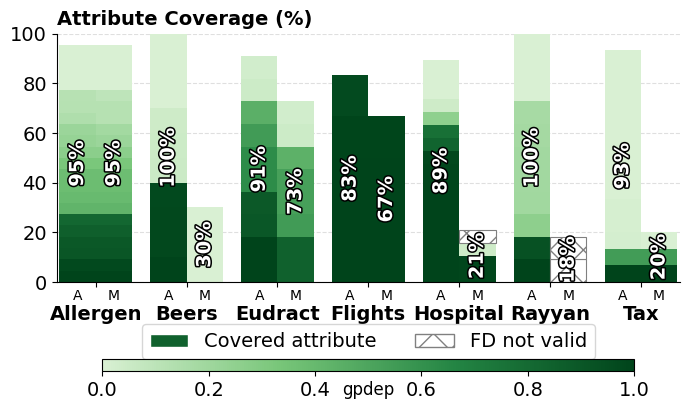

In [56]:
import matplotlib.patheffects as pe
def add_bar_label(ax, xpos, pct):
    ax.text(
        xpos,
        pct / 2,
        f"{pct:.0f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=14,
        fontweight="bold",
        rotation=90,
        path_effects=[
            pe.withStroke(linewidth=2.2, foreground="black")
        ],
        clip_on=False,
        zorder=10,
    )
tables = df["dataset"].tolist()
total_attributes = df["total_attributes"].to_numpy()

discovered_counts = np.array([len(discovered_attr_scores[d]) for d in tables])
reference_counts = np.array([len(reference_attr_scores[d]) for d in tables])
pair_max = np.maximum(discovered_counts, reference_counts)

# green gradient: light -> dark
gpdep_cmap = LinearSegmentedColormap.from_list(
    "gpdep_green",
    ["#d9f0d3", "#78c679", "#238443", "#00441b"]
)
gpdep_norm = Normalize(vmin=0, vmax=1)


def draw_attribute_bar(ax, x_pos, attr_map, total_attrs, pair_max_count, width, side):
    """
    Draw one stacked bar as:
      covered attributes (one small segment per attribute)
      + red gap to pair max
      + gray rest to total attrs
    """
    unit_pct = 100.0 / total_attrs
    bottom = 0.0

    matched_gpdeps = sorted(
        [v for v in attr_map.values() if v != UNMATCHED],
        reverse=True
    )
    unmatched_count = sum(v == UNMATCHED for v in attr_map.values())
    
    if side == "auto":
        bar_edgecolor = "none"
        bar_linewidth = 0.0
        unmatched_hatch = ""
    else:  # manual
        bar_edgecolor = "none"
        bar_linewidth = 1.0
        unmatched_hatch = 'x'
        
    # matched attributes, colored by gpdep
    for gpdep in matched_gpdeps:
        ax.bar(
            x_pos,
            unit_pct,
            width,
            bottom=bottom,
            color=gpdep_cmap(gpdep_norm(gpdep)),
            edgecolor=bar_edgecolor,
            linewidth=bar_linewidth,
        )
        bottom += unit_pct

    # unmatched reference attributes
    for _ in range(unmatched_count):
        ax.bar(
            x_pos,
            unit_pct,
            width,
            bottom=bottom,
            color="white",
            edgecolor="gray",
            hatch=unmatched_hatch,
            linewidth=0.8,
        )
        bottom += unit_pct

    covered_count = len(attr_map)

    # red gap up to pair max
    gap_count = pair_max_count - covered_count
    gap_count = 0
    if gap_count > 0:
        ax.bar(
            x_pos,
            gap_count * unit_pct,
            width,
            bottom=bottom,
            color="none",
            edgecolor="none",
            hatch="///",
            linewidth=0.8,
        )
        bottom += gap_count * unit_pct

    # gray rest to total relation size
    rest_count = total_attrs - pair_max_count
    rest_count = 0
    if rest_count > 0:
        ax.bar(
            x_pos,
            rest_count * unit_pct,
            width,
            bottom=bottom,
            color="#eeeeee",
            edgecolor="none",
            linewidth=0.6,
        )

    return covered_count * unit_pct


x = np.arange(len(tables))
width = 0.40

fig, ax = plt.subplots(figsize=(7.0, 4.2))

for i, dataset in enumerate(tables):
    total_attrs = DATASET_ATTR_COUNTS[dataset]
    pair_max_count = max(
        len(discovered_attr_scores[dataset]),
        len(reference_attr_scores[dataset])
    )

    # left = discovered
    disc_covered_pct = draw_attribute_bar(
        ax,
        x[i] - width/2,
        discovered_attr_scores[dataset],
        total_attrs,
        pair_max_count,
        width,
        side="auto",
    )

    # right = reference
    ref_covered_pct = draw_attribute_bar(
        ax,
        x[i] + width/2,
        reference_attr_scores[dataset],
        total_attrs,
        pair_max_count,
        width,
        side="manual",
    )

    # one label per covered region
    if disc_covered_pct > 0:
        matched_disc = [v for v in discovered_attr_scores[dataset].values() if v != UNMATCHED]
        label_color = "white"
        if matched_disc:
            avg_val = np.mean(matched_disc)
            label_color = text_color_for_value(avg_val, gpdep_cmap, gpdep_norm)

        #ax.text(
        #    x[i] - width/2,
        #    disc_covered_pct / 2,
        #    f"{disc_covered_pct:.1f}%",
        #    ha="center",
        #    va="center",
        #    color="black",
        #    fontsize=8,
        #    rotation=90,
        #)
        add_bar_label(ax, x[i] - width/2, disc_covered_pct)

    if ref_covered_pct > 0:
        matched_disc = [v for v in reference_attr_scores[dataset].values() if v != UNMATCHED]
        label_color = "white"
        if matched_disc:
            avg_val = np.mean(matched_disc)
            label_color = text_color_for_value(avg_val, gpdep_cmap, gpdep_norm)
        #ax.text(
        #    x[i] + width/2,
        #    ref_covered_pct / 2,
        #    f"{ref_covered_pct:.1f}%",
        #    ha="center",
        #    va="center",
        #    color="black",
        #    fontsize=8,
        #    rotation=90
        #)
        add_bar_label(ax, x[i] + width/2, ref_covered_pct)
    #ax.text(x[i] - width / 2, 103, "Auto", ha="center", va="bottom", fontsize=8, fontweight="bold")
    #ax.text(x[i] + width / 2, 103, "Manual", ha="center", va="bottom", fontsize=8, fontweight="bold")

#ax.text(0.02, 1.02, "Left bar = Automatic Discovery, Right bar = Manually defined", transform=ax.transAxes, fontsize=9, ha="left", va="bottom")

#ax.set_ylabel("Attribute coverage (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("")

ax.text(
    0.0, 1.02,
    "Attribute Coverage (%)",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(tables, fontsize=14, fontweight="bold")
ax.tick_params(axis="x", pad=13)

pad_below = -0.03
# Add A/M labels below each individual bar
for i in range(len(tables)):
    ax.text(
        x[i] - width / 2,
        pad_below,
        "A",
        transform=ax.get_xaxis_transform(),  # x=data coords, y=axes coords
        ha="center",
        va="top",
        fontsize=10,
        clip_on=False,
    )

    ax.text(
        x[i] + width / 2,
        pad_below,
        "M",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        clip_on=False,
    )
    
ax.set_xlim(x[0] - width - 0.03, x[-1] + width + 0.03)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis="y", labelsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# colorbar for gpdep
sm = plt.cm.ScalarMappable(cmap=gpdep_cmap, norm=gpdep_norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    #pad=0.2,       # distance below plot
    #fraction=0.05,  # thickness
    #aspect=40       # length/thickness ratio
    pad=0.23,
    fraction=0.035,
    aspect=45
)
cbar.set_label("gpdep", fontsize=12, labelpad=-14)
cbar.ax.tick_params(labelsize=14)

legend_handles = [
    Patch(facecolor=gpdep_cmap(gpdep_norm(0.85)), edgecolor="white", label="Covered attribute"),
    Patch(facecolor="white", edgecolor="gray", hatch="x", label="FD not valid"),
    #Patch(facecolor="white", edgecolor="black", linewidth=0.6, label="Automatic discovery bar"),
    #Patch(facecolor="white", edgecolor="black", linewidth=1.2, label="Manual rules bar"),
    #Patch(facecolor="#d95f5f", edgecolor="black", hatch="///", label="Gap to better coverage"),
    #Patch(facecolor="#cfcfcf", edgecolor="white", label="Not covered by either"),
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2,
    frameon=True,
    fontsize=14
)

plt.tight_layout()
plt.savefig("coverage_plot.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()